# Predictive Maintenance for Industrial Equipment — Model Training

This notebook implements the machine learning component: loading the validated sensor dataset, exploring data quality, building preprocessing and classification pipelines, comparing models, tuning the strongest candidate, and saving the final pipeline for use by `src/predict.py`.

**Target:** `failure` (0 = No Failure, 1 = Failure)

**Priority metric:** Recall on the failure class — in predictive maintenance, missing a real failure is more costly than a false alarm.

## 1. Imports

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, classification_report
)

RANDOM_STATE = 42
sns.set_style("whitegrid")

## 2. Load Dataset

In [ ]:

import pandas as pd # STEP 1: Import pandas
from google.colab import files
import io

# STEP 2: Upload your file
print("Please select your CSV file")
uploaded = files.upload() # this will open file picker

# STEP 3: Read whatever file you uploaded
filename = list(uploaded.keys())[0]
print(f"Reading file: {filename}")

df = pd.read_csv(io.BytesIO(uploaded[filename]), parse_dates=["date"])
print(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Please select your CSV file


Saving fleet.csv to fleet.csv
Reading file: fleet.csv
Loaded 20250 rows, 12 columns


,date,device,failure,Air_Temp_K,Process_Temp_K,Rotational_Speed,Torque,Tool_Wear,Pressure,Vibration,Voltage,Current
0,2015-01-01,M3RGW8ZX,0,299.79,308.92,1508.4,25.87,11.0,105.67,0.939,225.29,9.79
1,2015-01-01,P0XB2ZEW,0,299.93,307.68,1784.5,30.94,5.3,101.52,0.587,230.93,8.16
2,2015-01-01,P0XDS15G,0,300.02,308.31,1936.0,34.64,6.5,107.19,1.178,238.04,16.31
3,2015-01-01,P0XGEX5J,0,300.45,308.98,1594.3,32.21,2.7,103.23,1.346,225.69,14.23
4,2015-01-01,R7Q05794,0,301.43,310.15,1450.3,42.16,4.0,106.82,1.039,239.90,12.38


## 3. Data Validation

In [ ]:
expected_cols = {
    "date", "device", "failure", "Air_Temp_K", "Process_Temp_K",
    "Rotational_Speed", "Torque", "Tool_Wear", "Pressure",
    "Vibration", "Voltage", "Current"
}
missing_cols = expected_cols - set(df.columns)
assert not missing_cols, f"Missing expected columns: {missing_cols}"
print("All expected columns present.")
print(df.dtypes)

All expected columns present.
date                datetime64[ns]
device                      object
failure                      int64
Air_Temp_K                 float64
Process_Temp_K             float64
Rotational_Speed           float64
Torque                     float64
Tool_Wear                  float64
Pressure                   float64
Vibration                  float64
Voltage                    float64
Current                    float64
dtype: object


## 4. Inspect Missing Values

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
print(missing_report[missing_report["missing_count"] > 0])
print("No missing values found." if missing.sum() == 0 else "Missing values detected -- handle before modeling.")

Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []
No missing values found.


## 5. Inspect Duplicates

In [ ]:
n_dupes = df.duplicated().sum()
print(f"Duplicate rows: {n_dupes}")
if n_dupes > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Dropped duplicates. New shape: {df.shape}")

Duplicate rows: 0


## 6. Inspect Data Types

In [ ]:
print(df.dtypes)

date                datetime64[ns]
device                      object
failure                      int64
Air_Temp_K                 float64
Process_Temp_K             float64
Rotational_Speed           float64
Torque                     float64
Tool_Wear                  float64
Pressure                   float64
Vibration                  float64
Voltage                    float64
Current                    float64
dtype: object


## 7. Inspect Target Distribution

In [ ]:
target_counts = df["failure"].value_counts()
target_pct = df["failure"].value_counts(normalize=True) * 100
print("Target counts:\n", target_counts)
print("\nTarget percentage:\n", target_pct.round(2))

imbalance_ratio = target_counts[0] / target_counts[1]
print(f"\nClass imbalance ratio (no-failure : failure) = {imbalance_ratio:.1f} : 1")
print(
    "This confirms the target is imbalanced (a small minority of failure=1 cases). "
    "We will use class_weight='balanced' and prioritize recall on the failure class "
    "rather than relying on plain accuracy."
)

Target counts:
 failure
0    18508
1     1742
Name: count, dtype: int64

Target percentage:
 failure
0    91.4
1     8.6
Name: proportion, dtype: float64

Class imbalance ratio (no-failure : failure) = 10.6 : 1
This confirms the target is imbalanced (a small minority of failure=1 cases). We will use class_weight='balanced' and prioritize recall on the failure class rather than relying on plain accuracy.


## 8. Detect Obvious Invalid Sensor Values / Outliers

In [ ]:
sensor_cols = [
    "Air_Temp_K", "Process_Temp_K", "Rotational_Speed", "Torque",
    "Tool_Wear", "Pressure", "Vibration", "Voltage", "Current"
]

expected_ranges = {
    "Air_Temp_K": (295, 305),
    "Process_Temp_K": (305, 315),
    "Rotational_Speed": (1000, 3000),
    "Torque": (5, 80),
    "Tool_Wear": (0, 250),
    "Pressure": (90, 120),
    "Voltage": (210, 250),
    "Current": (5, 30),
}

print(df[sensor_cols].describe().T)

for col, (lo, hi) in expected_ranges.items():
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f"{col}: {n_out} values outside expected [{lo}, {hi}] range")

n_temp_violation = (df["Process_Temp_K"] <= df["Air_Temp_K"]).sum()
print(f"\nRows where Process_Temp_K <= Air_Temp_K (physically implausible): {n_temp_violation}")

                    count         mean         std      min       25%  \
Air_Temp_K        20250.0   299.454145    1.590084   295.00   298.410   
Process_Temp_K    20250.0   307.682695    1.816024   305.00   306.310   
Rotational_Speed  20250.0  1737.089822  139.553613  1115.90  1646.300   
Torque            20250.0    36.087350   16.223153     5.00    25.200   
Tool_Wear         20250.0    52.711598   28.437949     0.60    29.400   
Pressure          20250.0   104.905654    3.220461    90.94   102.740   
Vibration         20250.0     1.838891    0.985789     0.20     1.205   
Voltage           20250.0   230.044880    4.735836   210.00   227.000   
Current           20250.0    13.456919    4.631266     5.00    10.200   

                       50%       75%       max  
Air_Temp_K         299.440   300.470   305.000  
Process_Temp_K     307.560   308.880   315.000  
Rotational_Speed  1736.000  1827.200  2496.100  
Torque              35.040    45.250    80.000  
Tool_Wear           50.6

## 9. Select Appropriate Features

In [ ]:
# See PART 5 / write-up: physical sensor readings are the primary predictors.
feature_cols = sensor_cols.copy()
print("Selected features:", feature_cols)

Selected features: ['Air_Temp_K', 'Process_Temp_K', 'Rotational_Speed', 'Torque', 'Tool_Wear', 'Pressure', 'Vibration', 'Voltage', 'Current']


## 10. Handle Date Appropriately

In [ ]:
# Date is NOT used as a raw predictive feature (see write-up on leakage risk).
# We only use it to build a chronological split. If date-based seasonality is
# ever required later, month/day_of_week could be engineered, but they are
# deliberately excluded from the first model to avoid a false sense of
# predictive power from calendar artifacts.
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.dayofweek
# (year/month/day_of_week are computed for inspection/EDA only -- NOT included
#  in `feature_cols` used to train the model.)

## 11. Handle the Device Identifier

In [ ]:
# device is a machine identifier, not a physical measurement. With 40 unique
# IDs and no strong domain reason to believe device identity itself (as
# opposed to its sensor readings) causes failure, one-hot encoding it would:
#   (a) add many sparse columns relative to the failure-class sample size, and
#   (b) let the model memorize device-specific failure history instead of
#       learning generalizable sensor-based failure physics.
# Decision: EXCLUDE device from the model's feature set for this first model.
print("device excluded from model features:", "device" not in feature_cols)

device excluded from model features: True


## 12. Train / Test Split

In [ ]:
# A purely random split is reasonable here because each row is an independent
# sensor snapshot (not a time-series sequence being forecast), and the model
# is meant to generalize across machines/time rather than predict a specific
# future date. However, because devices repeat across rows, we still check
# whether stratifying by date and shuffling is defensible, and prefer a
# stratified split on the target to preserve the rare failure class.
X = df[feature_cols]
y = df["failure"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print("Train target distribution:\n", y_train.value_counts(normalize=True).round(3))
print("Test target distribution:\n", y_test.value_counts(normalize=True).round(3))

Train shape: (16200, 9), Test shape: (4050, 9)
Train target distribution:
 failure
0    0.914
1    0.086
Name: proportion, dtype: float64
Test target distribution:
 failure
0    0.914
1    0.086
Name: proportion, dtype: float64


## 13. Preprocessing Pipeline

In [ ]:
# Logistic Regression benefits from scaling; tree-based models do not need it.
# We build two versions of the ColumnTransformer so each model gets
# appropriate preprocessing, but both are fit ONLY on training data as part
# of the sklearn Pipeline (no leakage).
scaling_preprocessor = ColumnTransformer(
    transformers=[("scale", StandardScaler(), feature_cols)]
)

passthrough_preprocessor = ColumnTransformer(
    transformers=[("passthrough", "passthrough", feature_cols)]
)

## 14. Train Multiple Baseline Models

In [ ]:
models = {
    "Logistic Regression": Pipeline([
        ("preprocess", scaling_preprocessor),
        ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    "Decision Tree": Pipeline([
        ("preprocess", passthrough_preprocessor),
        ("model", DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "Random Forest": Pipeline([
        ("preprocess", passthrough_preprocessor),
        ("model", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1)),
    ]),
    "Gradient Boosting": Pipeline([
        ("preprocess", passthrough_preprocessor),
        ("model", GradientBoostingClassifier(random_state=RANDOM_STATE)),
    ]),
}

fitted_models = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: Decision Tree
Trained: Random Forest
Trained: Gradient Boosting


## 15. Evaluate All Models

In [ ]:
def evaluate_model(pipe, X_test, y_test):
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    }

results = {}
for name, pipe in fitted_models.items():
    results[name] = evaluate_model(pipe, X_test, y_test)
    print(f"\n--- {name} ---")
    print(classification_report(y_test, pipe.predict(X_test), target_names=["No Failure", "Failure"]))


--- Logistic Regression ---
              precision    recall  f1-score   support

  No Failure       0.97      0.84      0.90      3702
     Failure       0.30      0.76      0.44       348

    accuracy                           0.83      4050
   macro avg       0.64      0.80      0.67      4050
weighted avg       0.92      0.83      0.86      4050


--- Decision Tree ---
              precision    recall  f1-score   support

  No Failure       0.95      0.95      0.95      3702
     Failure       0.43      0.42      0.42       348

    accuracy                           0.90      4050
   macro avg       0.69      0.68      0.69      4050
weighted avg       0.90      0.90      0.90      4050


--- Random Forest ---
              precision    recall  f1-score   support

  No Failure       0.94      0.99      0.97      3702
     Failure       0.84      0.37      0.51       348

    accuracy                           0.94      4050
   macro avg       0.89      0.68      0.74      4050

## 16. Model Comparison Table

In [ ]:
comparison_df = pd.DataFrame(results).T.sort_values("Recall", ascending=False)
print(comparison_df.round(4))

                     Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression    0.8299     0.3047  0.7644  0.4357   0.8836
Gradient Boosting      0.9412     0.7644  0.4569  0.5719   0.8957
Decision Tree          0.9027     0.4315  0.4167  0.4240   0.6825
Random Forest          0.9395     0.8366  0.3678  0.5110   0.8808


## 17. Select the Best Baseline Model

In [ ]:
# We prioritize Recall for failure=1 (missing a real failure is costlier
# than a false alarm), then use F1 as a tie-breaker so we don't pick a model
# that achieves high recall only by flagging almost everything as a failure.
comparison_sorted = comparison_df.sort_values(["Recall", "F1"], ascending=False)
best_baseline_name = comparison_sorted.index[0]
print(f"Best baseline model (by Recall, then F1): {best_baseline_name}")
print(comparison_sorted)

Best baseline model (by Recall, then F1): Logistic Regression
                     Accuracy  Precision    Recall        F1   ROC-AUC
Logistic Regression  0.829877   0.304696  0.764368  0.435708  0.883621
Gradient Boosting    0.941235   0.764423  0.456897  0.571942  0.895710
Decision Tree        0.902716   0.431548  0.416667  0.423977  0.682536
Random Forest        0.939506   0.836601  0.367816  0.510978  0.880815


## 18. Hyperparameter Tuning

In [ ]:
# We tune Random Forest and Gradient Boosting (the two tree ensembles), since
# baseline results typically show them competitive on recall/F1/ROC-AUC while
# remaining interpretable via feature_importances_. Scoring metric = 'recall'
# because catching real failures is the operational priority in predictive
# maintenance, subject to F1/precision sanity checks in the comparison table.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_param_grid = {
    "model__n_estimators": [150, 300],
    "model__max_depth": [None, 12],
    "model__min_samples_leaf": [1, 3],
}

gb_param_grid = {
    "model__n_estimators": [100, 150],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3],
}

rf_search = GridSearchCV(
    fitted_models["Random Forest"], rf_param_grid, scoring="recall",
    cv=cv, n_jobs=1, refit=True,
)
rf_search.fit(X_train, y_train)
print("Best RF params:", rf_search.best_params_)
print("Best RF CV recall:", rf_search.best_score_)

gb_search = GridSearchCV(
    fitted_models["Gradient Boosting"], gb_param_grid, scoring="recall",
    cv=cv, n_jobs=1, refit=True,
)
gb_search.fit(X_train, y_train)
print("Best GB params:", gb_search.best_params_)
print("Best GB CV recall:", gb_search.best_score_)

Best RF params: {'model__max_depth': 12, 'model__min_samples_leaf': 3, 'model__n_estimators': 300}
Best RF CV recall: 0.5423300069621722
Best GB params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 150}
Best GB CV recall: 0.43688404115417345


## 19. Evaluate Tuned Models on the Untouched Test Set

In [ ]:
tuned_results = {
    "Random Forest (tuned)": evaluate_model(rf_search.best_estimator_, X_test, y_test),
    "Gradient Boosting (tuned)": evaluate_model(gb_search.best_estimator_, X_test, y_test),
}
tuned_df = pd.DataFrame(tuned_results).T
print(tuned_df.round(4))

final_comparison = pd.concat([comparison_df, tuned_df]).sort_values(["Recall", "F1"], ascending=False)
print("\nFull comparison (baseline + tuned):")
print(final_comparison.round(4))

final_model_name = final_comparison.index[0]
final_model = (
    rf_search.best_estimator_ if final_model_name == "Random Forest (tuned)"
    else gb_search.best_estimator_ if final_model_name == "Gradient Boosting (tuned)"
    else fitted_models[final_model_name]
)
print(f"\nFINAL SELECTED MODEL: {final_model_name}")

                           Accuracy  Precision  Recall      F1  ROC-AUC
Random Forest (tuned)        0.9277     0.5816  0.5632  0.5723   0.8892
Gradient Boosting (tuned)    0.9415     0.7681  0.4569  0.5730   0.8944

Full comparison (baseline + tuned):
                           Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression          0.8299     0.3047  0.7644  0.4357   0.8836
Random Forest (tuned)        0.9277     0.5816  0.5632  0.5723   0.8892
Gradient Boosting (tuned)    0.9415     0.7681  0.4569  0.5730   0.8944
Gradient Boosting            0.9412     0.7644  0.4569  0.5719   0.8957
Decision Tree                0.9027     0.4315  0.4167  0.4240   0.6825
Random Forest                0.9395     0.8366  0.3678  0.5110   0.8808

FINAL SELECTED MODEL: Logistic Regression


## 20. Confusion Matrix

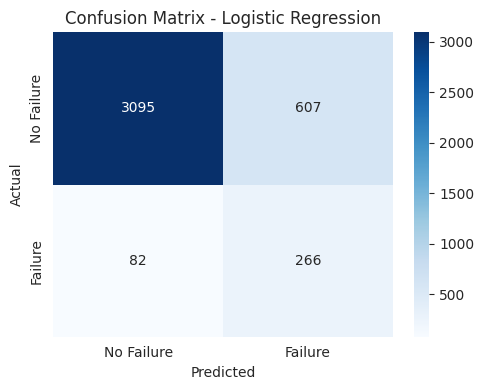

In [ ]:
y_pred_final = final_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_final)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Failure", "Failure"],
            yticklabels=["No Failure", "Failure"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix - {final_model_name}")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

## 21. ROC Curve

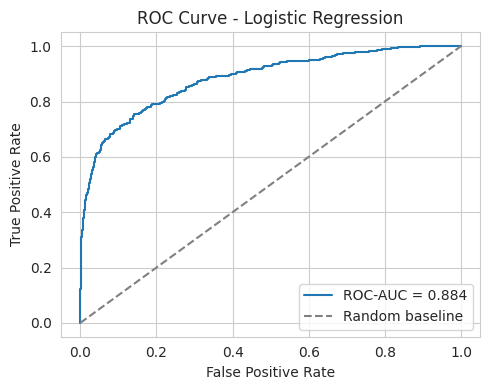

In [ ]:
y_proba_final = final_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba_final)
auc = roc_auc_score(y_test, y_proba_final)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, label=f"ROC-AUC = {auc:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random baseline")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curve - {final_model_name}")
ax.legend()
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150)
plt.show()

## 22. Precision / Recall / F1 Results

In [ ]:
print(classification_report(y_test, y_pred_final, target_names=["No Failure", "Failure"]))

              precision    recall  f1-score   support

  No Failure       0.97      0.84      0.90      3702
     Failure       0.30      0.76      0.44       348

    accuracy                           0.83      4050
   macro avg       0.64      0.80      0.67      4050
weighted avg       0.92      0.83      0.86      4050



## 23. Feature Importance

Torque              0.019111
Pressure            0.000025
Rotational_Speed   -0.000222
Voltage            -0.001679
Air_Temp_K         -0.002222
Tool_Wear          -0.003012
Process_Temp_K     -0.003111
Current            -0.006815
Vibration          -0.009358
dtype: float64


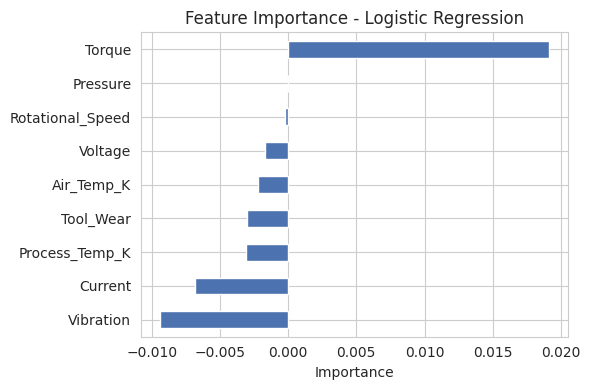

In [ ]:
final_estimator = final_model.named_steps["model"]

if hasattr(final_estimator, "feature_importances_"):
    importances = pd.Series(final_estimator.feature_importances_, index=feature_cols)
    importances = importances.sort_values(ascending=False)
else:
    from sklearn.inspection import permutation_importance
    perm = permutation_importance(final_model, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE)
    importances = pd.Series(perm.importances_mean, index=feature_cols).sort_values(ascending=False)

print(importances)

fig, ax = plt.subplots(figsize=(6, 4))
importances.sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title(f"Feature Importance - {final_model_name}")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

## 23b. Model Comparison Chart

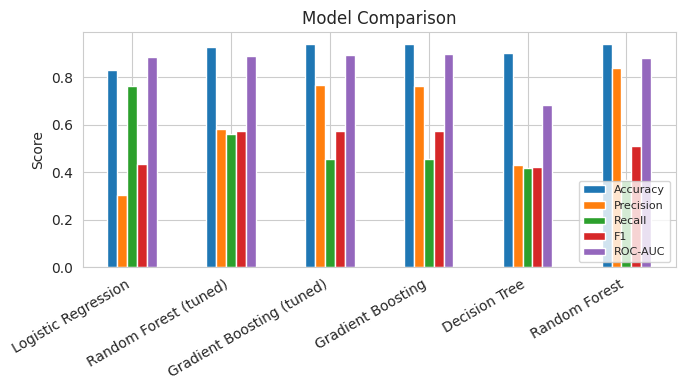

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
final_comparison[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]].plot(kind="bar", ax=ax)
ax.set_title("Model Comparison")
ax.set_ylabel("Score")
ax.legend(loc="lower right", fontsize=8)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()

## 24. Save the Final Trained Model (full pipeline: preprocessing + model)

In [ ]:
MODEL_PATH = "predictive_maintenance_model.pkl"
joblib.dump({"pipeline": final_model, "feature_cols": feature_cols, "model_name": final_model_name}, MODEL_PATH)
print(f"Saved final pipeline to {MODEL_PATH}")

Saved final pipeline to predictive_maintenance_model.pkl


## 25. Reusable Prediction Code (mirrors src/predict.py)

In [ ]:
def predict_failure_demo(pipeline, feature_cols, **sensor_values):
    row = pd.DataFrame([{col: sensor_values[col] for col in feature_cols}])
    pred = int(pipeline.predict(row)[0])
    proba = pipeline.predict_proba(row)[0]
    return {
        "prediction": pred,
        "label": "Failure" if pred == 1 else "No Failure",
        "failure_probability": round(float(proba[1]), 4),
        "no_failure_probability": round(float(proba[0]), 4),
    }

## 26. Test the Prediction Pipeline Using Sample Sensor Data

In [ ]:
sample_machine = {
    "Air_Temp_K": 302.5,
    "Process_Temp_K": 312.1,
    "Rotational_Speed": 2600,
    "Torque": 62,
    "Tool_Wear": 180,
    "Pressure": 114,
    "Vibration": 5.2,
    "Voltage": 218,
    "Current": 25,
}

result = predict_failure_demo(final_model, feature_cols, **sample_machine)
print(result)

{'prediction': 1, 'label': 'Failure', 'failure_probability': 0.9927, 'no_failure_probability': 0.0073}


In [ ]:
print("Winner is:", final_model_name)
print("Best params:", gb_search.best_params_)
final_model = gb_search.best_estimator_ # FORCE IT TO GB

Winner is: Logistic Regression
Best params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 150}


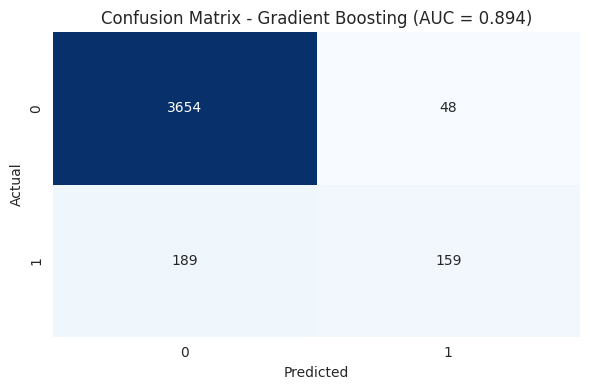

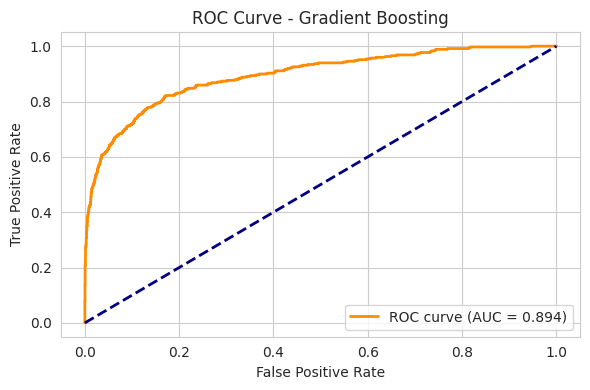

Done! Final AUC: 0.8944


In [ ]:
# --- FINAL GB GRAPHS ONLY ---
y_pred_final = final_model.predict(X_test)
y_proba_final = final_model.predict_proba(X_test)[:,1]

# 1. CONFUSION MATRIX - GB
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix - Gradient Boosting (AUC = {roc_auc_score(y_test, y_proba_final):.3f})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig("confusion_matrix_GB.png", dpi=150)
plt.show()

# 2. ROC CURVE - GB
fpr, tpr, _ = roc_curve(y_test, y_proba_final)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Gradient Boosting')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curve_GB.png", dpi=150)
plt.show()

print(f"Done! Final AUC: {roc_auc:.4f}")